work log: 
Simply speaking, the main target of the assignment is to get data from ElHub using API calls, plot the data in the notebook, and send data to Mongo database, from which it will be later read, processed, and displayed on StreamLit app. Seems easy enough. But! The problems came from docker. to optimize the process, the jupyter otebook, thats responsible for primary data acquisition, transfer. and processing, needed to be run in docker container. Wouldnt be an issue, right? Well, the problem was that everything was set up and code was under development, some errors kept popping up. Firstly, cassandra and jupyter were not able to communicate. The problem was that I, due to lack of experience, made a mistake of putting those two on differet networks. Luckily, the issue was fixed easily with two commands: disconnect from one network and connect to the other. The problems didnt stop on that. The second major issue was that Spark was not willing to work properly. All the time it was complaining on Windows and wanted to install some additional stuff. After many hours and exhaustion of any hopes, the problem was solved with great and mighty ChatGPT. Appears, that even though everything was set up correctly, on one network, with correct versions, when i was running juoyter from VScode it didnt work cause VSCode wasnt connected to docker container. Rookie mistake... As an anxious person, who is not very combortable with installing some random stuff on windows, it was decided to run the notebook locally from browser. It saved me from panicing about installing something, that i dont understand. After that all went smoothly and sound. For future generations and to future me:  
- put all personal info (username/password/etc) to secrets from the beginning
- dont forget to add location of your secrets to yml and every time you change something in yml, dont forget to recreate container. NB! requirement file is very useful, cause each time you will recreate the container, you will have to reinstall libraries
- if you run streamlit online, dont forget to add your secrets to the app settings, otherwise it will complain. 
- chatgpt is a great tool for code generation, but you have to think and analyze yourself. Sometimes is uch easier and faster to find an issue and debug it yourself.

This assignment strengthen my ability to find a problem and solution, even for something that you are not expert in or not fully understand. Great skill in life.

AI usage: chatgpt was used to generate base code and was of help sometimes with debugging.
Links:
- Github notebook :  https://github.com/Viktoria0720/IND320_VY/tree/assignment2/ASSIGNMENTS/PART2/notebooks
- Github streamlit:  https://github.com/Viktoria0720/IND320_VY/tree/assignment2/ASSIGNMENTS/PART1/streamlit_app_1
- Streamlit:  https://ind320vy-app1v2.streamlit.app/

In [1]:
import os, requests, pandas as pd
from datetime import datetime, timezone, timedelta

# === Assignment config ===
YEAR = 2021
CHOSEN_AREA = "NO1"    # used by the plots
USE_MOCK = False       # set True to test full pipeline without calling the API

# === Docker service names / ports ===
CASSANDRA_HOST = os.getenv("CASSANDRA_HOST", "my_cassandra")
CASSANDRA_PORT = int(os.getenv("CASSANDRA_PORT", "9042"))

# === MongoDB Atlas (live cloud) ===
MONGO_URI = os.getenv("MONGO_URI","")

# === Elhub v0 public endpoint (no auth) ===
ELHUB_V0_BASE = "https://api.elhub.no/energy-data/v0"
ENTITY = "price-areas"
DATASET = "PRODUCTION_PER_GROUP_MBA_HOUR"

print(f"Cassandra = {CASSANDRA_HOST}:{CASSANDRA_PORT}")
print(f"Mongo URI set? {'yes' if bool(MONGO_URI) else 'no'}")
print(f"Endpoint = {ELHUB_V0_BASE}/{ENTITY}?dataset={DATASET}")


Cassandra = my_cassandra:9042
Mongo URI set? yes
Endpoint = https://api.elhub.no/energy-data/v0/price-areas?dataset=PRODUCTION_PER_GROUP_MBA_HOUR


In [2]:
# Spark is our engine to write/read Cassandra conveniently.
from pyspark.sql import SparkSession

# Maven coordinate for the Spark–Cassandra connector matching Spark 3.5.x and Scala 2.12
CASSANDRA_CONNECTOR = "com.datastax.spark:spark-cassandra-connector_2.12:3.5.1"

spark = (
    SparkSession.builder
    .appName("IND320-Elhub-v0-Production")
    # Pull connector jar automatically
    .config("spark.jars.packages", CASSANDRA_CONNECTOR)
    # Tell connector where Cassandra lives (container name + port)
    .config("spark.cassandra.connection.host", CASSANDRA_HOST)
    .config("spark.cassandra.connection.port", str(CASSANDRA_PORT))
    # Keep everything in UTC; avoids DST headaches
    .config("spark.sql.session.timeZone", "UTC")
    .getOrCreate()
)
print("Spark:", spark.version)

# Use Python driver once to create keyspace+table (simpler than doing it via Spark SQL)
from cassandra.cluster import Cluster

cluster = Cluster([CASSANDRA_HOST], port=CASSANDRA_PORT)
session = cluster.connect()

# SimpleStrategy is OK for a single-node dev/test cluster
session.execute("""
CREATE KEYSPACE IF NOT EXISTS elhub
WITH replication = {'class': 'SimpleStrategy', 'replication_factor': '1'}
""")

# Table stores hourly production; primary key lets query by area+group ordered by time
session.execute("""
CREATE TABLE IF NOT EXISTS elhub.production_hourly (
    pricearea text,
    productiongroup text,
    starttime timestamp,
    quantitykwh double,
    PRIMARY KEY ((pricearea, productiongroup), starttime)
) WITH CLUSTERING ORDER BY (starttime ASC)
""")

cluster.shutdown()
print("Cassandra schema ready.")


Spark: 3.5.1
Cassandra schema ready.


In [3]:
import socket, sys
#Connect to cassandra

HOST = "my_cassandra"  
PORT = 9042             

print("Checking DNS…")
try:
    print(socket.gethostbyname_ex(HOST))
except Exception as e:
    print("DNS error:", e)
    sys.exit(0)

print("Checking TCP…")
s = socket.socket()
s.settimeout(3)
try:
    s.connect((HOST, PORT))
    print(f"TCP OK to {HOST}:{PORT}")
finally:
    s.close()


Checking DNS…
('my_cassandra', [], ['172.20.0.2'])
Checking TCP…
TCP OK to my_cassandra:9042


In [9]:
# --- REQUIREMENTS ---
import time
import requests
import pandas as pd
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo 

# --- API SETTINGS ---
BASE_URL = "https://api.elhub.no/energy-data/v0/price-areas"
DATASET = "PRODUCTION_PER_GROUP_MBA_HOUR"

# --- FORMAT DATES AS YOU SPECIFIED (+02:00 URL-encoded as %2B02:00) ---
def format_date(dt_obj: datetime) -> str:
    """Formats local Oslo time with an explicit +02:00 (encoded) offset for Elhub."""
    # NOTE: We treat 2021 as Europe/Oslo wall time; in 2021 Oslo is +01:00 winter / +02:00 summer,
    # but you asked to force +02:00 in the query. This encodes '+02:00' as '%2B02:00'.
    return dt_obj.strftime("%Y-%m-%dT%H:%M:%S%%2B02:00")

# --- FETCH MONTHLY DATA FOR 2021 ---
all_records = []
headers = {"Accept": "application/json"}

print("=== Fetching Elhub 2021 (monthly) via startDate/endDate, +02:00 encoded ===")
for month in range(1, 13):
    start = datetime(2021, month, 1)
    next_month = (start + timedelta(days=32)).replace(day=1)
    end = next_month - timedelta(seconds=1)

    start_str = format_date(start)
    end_str   = format_date(end)

    url = f"{BASE_URL}?dataset={DATASET}&startDate={start_str}&endDate={end_str}"
    print(f"\n→ Fetching {start.date()} → {end.date()}")
    resp = requests.get(url, headers=headers, timeout=60)
    if resp.status_code != 200:
        print(f"  ❌ HTTP {resp.status_code}")
        continue

    raw = resp.json()
    data = raw.get("data", raw) if isinstance(raw, dict) else raw
    if not isinstance(data, list):
        print("  ⚠ Unexpected payload; skipping month")
        continue

    month_rows = 0
    for entry in data:
        attrs = entry.get("attributes", {}) if isinstance(entry, dict) else {}
        price_area = attrs.get("name") or entry.get("name") or "UNKNOWN"
        series = attrs.get("productionPerGroupMbaHour", [])
        if not isinstance(series, list):
            continue

        for r in series:
            # Skip placeholders
            if r.get("productionGroup") == "*":
                continue
            # Normalize keys we care about
            pg = r.get("productionGroup") or r.get("group") or r.get("groupCode")
            ts = (r.get("startTime") or r.get("fromTime") or r.get("time")
                  or r.get("datetime") or r.get("start") or r.get("from_time"))
            qk = (r.get("quantityKwh") or r.get("quantity") or r.get("value")
                  or r.get("kwh") or r.get("amount"))
            if pg and ts and qk is not None:
                all_records.append({
                    "priceArea": price_area,
                    "productionGroup": pg,
                    "startTime": ts,
                    "quantityKwh": qk,
                })
                month_rows += 1

    print(f"  ✅ {month_rows} rows added")
    time.sleep(1) 

print(f"\nTotal raw rows collected: {len(all_records)}")

# --- TO DATAFRAME (normalize, filter strictly to 2021, sort) ---
df = pd.DataFrame(all_records)
if df.empty:
    raise RuntimeError("No rows collected from Elhub. (The server may ignore startDate/endDate.)")

# Parse timestamp; Elhub returns an offset in the string so this becomes tz-aware
df["startTime"] = pd.to_datetime(df["startTime"], utc=True, errors="coerce")
df["quantityKwh"] = pd.to_numeric(df["quantityKwh"], errors="coerce")

# Filter by **Europe/Oslo** year 2021 
df_oslo = df.copy()
df_oslo["startTimeOslo"] = df_oslo["startTime"].dt.tz_convert(ZoneInfo("Europe/Oslo"))
df_2021 = df_oslo[df_oslo["startTimeOslo"].dt.year == 2021].copy()

# Keep canonical columns; sort
df_final = (
    df_2021[["priceArea", "productionGroup", "startTime", "quantityKwh"]]
    .sort_values(["priceArea", "startTime"], kind="stable")
    .reset_index(drop=True)
)

print("\n=== Summary ===")
print("Rows (post-2021 filter):", len(df_final))
if not df_final.empty:
    print("Span UTC:", df_final["startTime"].min(), "→", df_final["startTime"].max())
    print("Areas:", df_final["priceArea"].nunique(),
          "| Groups:", df_final["productionGroup"].nunique())

# Inspect a few
df_final.head(10)


=== Fetching Elhub 2021 (monthly) via startDate/endDate, +02:00 encoded ===

→ Fetching 2021-01-01 → 2021-01-31
  ✅ 13894 rows added

→ Fetching 2021-02-01 → 2021-02-28
  ✅ 13124 rows added

→ Fetching 2021-03-01 → 2021-03-31
  ✅ 15091 rows added

→ Fetching 2021-04-01 → 2021-04-30
  ✅ 15568 rows added

→ Fetching 2021-05-01 → 2021-05-31
  ✅ 16122 rows added

→ Fetching 2021-06-01 → 2021-06-30
  ✅ 15721 rows added

→ Fetching 2021-07-01 → 2021-07-31
  ✅ 16195 rows added

→ Fetching 2021-08-01 → 2021-08-31
  ✅ 16093 rows added

→ Fetching 2021-09-01 → 2021-09-30
  ✅ 15362 rows added

→ Fetching 2021-10-01 → 2021-10-31
  ✅ 15492 rows added

→ Fetching 2021-11-01 → 2021-11-30
  ✅ 15131 rows added

→ Fetching 2021-12-01 → 2021-12-31
  ✅ 15419 rows added

Total raw rows collected: 183212

=== Summary ===
Rows (post-2021 filter): 183212
Span UTC: 2020-12-31 23:00:00+00:00 → 2021-12-31 22:00:00+00:00
Areas: 5 | Groups: 5


,priceArea,productionGroup,startTime,quantityKwh
0,NO1,hydro,2020-12-31 23:00:00+00:00,2507716.800
1,NO1,solar,2020-12-31 23:00:00+00:00,6.106
2,NO1,thermal,2020-12-31 23:00:00+00:00,51369.035
3,NO1,wind,2020-12-31 23:00:00+00:00,937.072
4,NO1,hydro,2021-01-01 00:00:00+00:00,2494728.000
5,NO1,solar,2021-01-01 00:00:00+00:00,4.030
6,NO1,thermal,2021-01-01 00:00:00+00:00,51673.934
7,NO1,wind,2021-01-01 00:00:00+00:00,649.068
8,NO1,hydro,2021-01-01 01:00:00+00:00,2486777.500
9,NO1,solar,2021-01-01 01:00:00+00:00,3.982


In [19]:
from pyspark.sql import functions as F

# Spark DataFrame with lowercase Cassandra column names
df_spark = spark.createDataFrame(df_final.rename(columns={
    "priceArea":"pricearea",
    "productionGroup":"productiongroup",
    "startTime":"starttime",
    "quantityKwh":"quantitykwh",
}))

# Append into elhub.production_hourly
df_spark.write.format("org.apache.spark.sql.cassandra") \
    .options(keyspace="elhub", table="production_hourly") \
    .mode("append").save()

# Small confirmation
total_rows = (spark.read.format("org.apache.spark.sql.cassandra")
              .options(keyspace="elhub", table="production_hourly").load().count())
print("Cassandra row count now:", total_rows)


Cassandra row count now: 183212


In [15]:
# 1) Load current table
df_cas = (spark.read.format("org.apache.spark.sql.cassandra")
          .options(keyspace="elhub", table="production_hourly")
          .load())

# 2) Parse starttime -> timestamp (Spark reads ISO8601 strings fine)
df_ts = df_cas.withColumn("starttime_ts", F.to_timestamp("starttime"))

# 3) Convert to local time and keep only 2021
df_2021 = (df_ts
    .withColumn("starttime_oslo", F.from_utc_timestamp("starttime_ts", "Europe/Oslo"))
    .filter(F.year("starttime_oslo") == 2021)
    .select("pricearea", "productiongroup", "starttime", "quantitykwh")   # back to original cols
)

# Quick sanity check
print("Before:", df_cas.count(), "After (2021 only):", df_2021.count())


Before: 204595 After (2021 only): 184653


In [16]:
# Execute CQL through the connector's JVM API
jvm = spark._jvm
jsc = spark.sparkContext._jsc
conf = jsc.sc().getConf()
connector = jvm.com.datastax.spark.connector.cql.CassandraConnector.apply(conf)
session = connector.openSession()
session.execute("TRUNCATE elhub.production_hourly")
session.close()
print("TRUNCATE elhub.production_hourly done.")

TRUNCATE elhub.production_hourly done.


In [17]:
(df_2021.write.format("org.apache.spark.sql.cassandra")
    .options(keyspace="elhub", table="production_hourly")
    .mode("append")
    .save())
print("Reloaded 2021-only rows into elhub.production_hourly")


Reloaded 2021-only rows into elhub.production_hourly


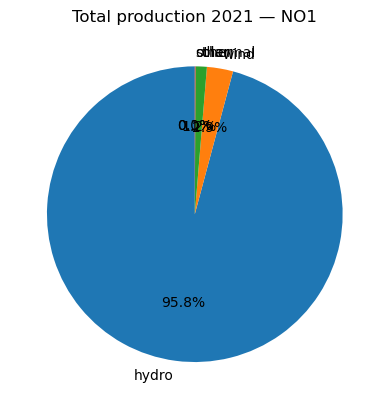

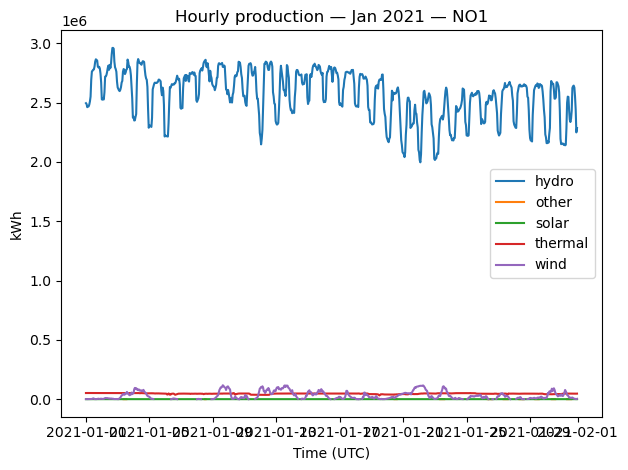

In [20]:
# Ensure plots render inline in Jupyter
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

import matplotlib.pyplot as plt
from pathlib import Path

# Read back from Cassandra for plotting (as requested in assignment)
prod = (spark.read.format("org.apache.spark.sql.cassandra")
        .options(keyspace="elhub", table="production_hourly").load()
        .select("pricearea","productiongroup","starttime","quantitykwh"))

# Limit strictly to YEAR to avoid mixing if you run multiple years later
prod = prod.filter(F.year("starttime")==YEAR)

# ----- Pie: total production of the year by group for chosen price area -----
totals = (prod.filter(F.col("pricearea")==CHOSEN_AREA)
          .groupBy("productiongroup")
          .agg(F.sum("quantitykwh").alias("sumKwh"))
          .orderBy(F.desc("sumKwh"))).toPandas()

plt.figure()
if not totals.empty:
    plt.pie(totals["sumKwh"], labels=totals["productiongroup"], autopct="%1.1f%%", startangle=90)
    plt.title(f"Total production {YEAR} — {CHOSEN_AREA}")
else:
    plt.text(0.5,0.5,"No data", ha="center")
plt.show()

# ----- Line: first month (January) with separate lines per group -----
jan = (prod.filter((F.col("pricearea")==CHOSEN_AREA) &
                   (F.col("starttime") >= F.to_timestamp(F.lit(f"{YEAR}-01-01T00:00:00Z"))) &
                   (F.col("starttime") <  F.to_timestamp(F.lit(f"{YEAR}-02-01T00:00:00Z"))))
       .groupBy("productiongroup","starttime")
       .agg(F.sum("quantitykwh").alias("kWh"))).toPandas()

plt.figure()
if not jan.empty:
    pvt = jan.pivot(index="starttime", columns="productiongroup", values="kWh").sort_index()
    for col in pvt.columns:
        plt.plot(pvt.index, pvt[col], label=col)
    plt.legend(); plt.title(f"Hourly production — Jan {YEAR} — {CHOSEN_AREA}")
    plt.xlabel("Time (UTC)"); plt.ylabel("kWh"); plt.tight_layout()
else:
    plt.text(0.5,0.5,"No January data", ha="center")
plt.show()


In [22]:
if not MONGO_URI:
    print("⚠️  MONGO_URI is not set; skipping Atlas export. Set it and re-run this cell.")
else:
    from pymongo import MongoClient, ASCENDING

    # Connect to Atlas using SRV URI from env
    client = MongoClient(MONGO_URI)
    db = client["energy"]  # choose DB explicitly
    client.admin.command("ping")
    print("Connected to", db.name)
    coll = db["elhub_production_2021"]  # collection used by the Streamlit page

    # Clean + index for fast lookups
    coll.delete_many({})
    coll.create_index([("priceArea", ASCENDING), ("productionGroup", ASCENDING), ("startTime", ASCENDING)])

    # Convert timestamps to string UTC (ISO Z) for portability
    df_out = df_final.copy()
    df_out["startTime"] = df_out["startTime"].dt.tz_convert("UTC").dt.strftime("%Y-%m-%dT%H:%M:%SZ")

    # Insert in batches to avoid payload limits
    BATCH = 200_000
    inserted = 0
    for i in range(0, len(df_out), BATCH):
        batch = df_out.iloc[i:i+BATCH]
        if not batch.empty:
            coll.insert_many(batch.to_dict(orient="records"))
            inserted += len(batch)

    print(f"Inserted {inserted} documents into Atlas → {coll.full_name}")


Connected to energy
Inserted 183212 documents into Atlas → energy.elhub_production_2021
